In [6]:
import numpy as np

N, d, steps = 3, 4, 15

S = np.array([
    [0.70, 0.10, 0.10, 0.10],
    [0.00, 0.50, 0.30, 0.20],
    [0.25, 0.25, 0.25, 0.25]
])
B = S.copy()
Gamma = np.diag([0.6, 0.1, 0.2])
A = np.diag([0.3, 0.2, 0.1])
W = np.array([
    [0.0, 0.8, 0.2],
    [0.4, 0.0, 0.6],
    [0.5, 0.5, 0.0]
])
I = np.eye(N)
M = A + (I - A) @ W 

# --- 2. Simulation with History Tracking ---
# We will store the beliefs at each step so we can plot them
history = [B.copy()]

for t in range(steps):
    B = (Gamma @ S) + ((I - Gamma) @ M @ B)
    history.append(B.copy())

# Convert history to a 3D numpy array for easy slicing: shape (steps, agents, outcomes)
history = np.array(history)

In [7]:
import matplotlib.pyplot as plt

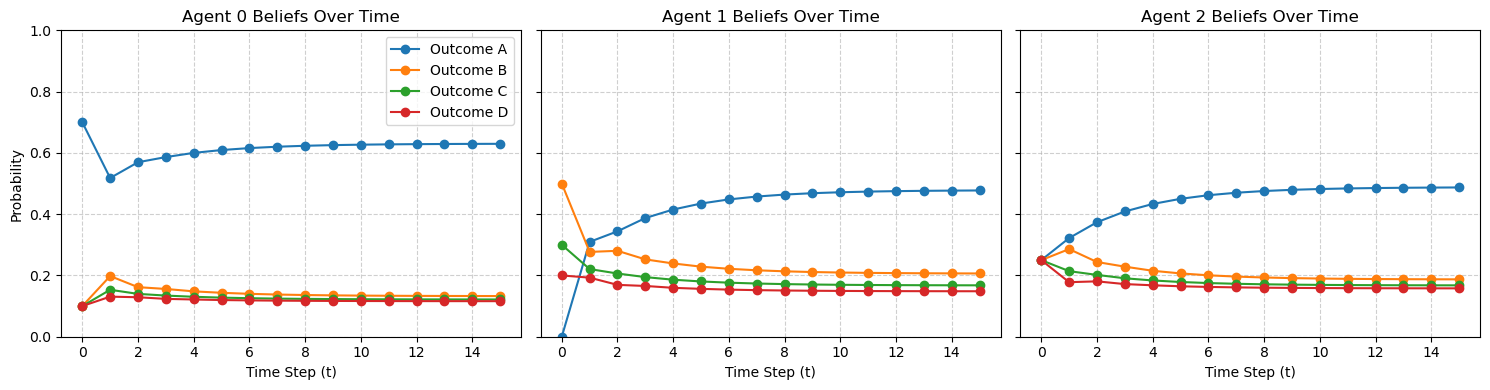

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
outcomes = ['Outcome A', 'Outcome B', 'Outcome C', 'Outcome D']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(N):
    ax = axes[i]
    for j in range(d):
        ax.plot(range(steps + 1), history[:, i, j], marker='o', 
                label=outcomes[j], color=colors[j])
    
    ax.set_title(f"Agent {i} Beliefs Over Time")
    ax.set_xlabel("Time Step (t)")
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.6)

axes[0].set_ylabel("Probability")
axes[0].legend()
plt.tight_layout()
plt.show()

In [9]:
B_analytical = np.linalg.inv(I - (I - Gamma) @ M) @ (Gamma @ S)

print("\nSimulated Beliefs at step 15:")
print(np.round(B, 4))

print("\nAnalytical Steady State (t -> infinity):")
print(np.round(B_analytical, 4))


Simulated Beliefs at step 15:
[[0.6296 0.1327 0.1216 0.116 ]
 [0.4774 0.2065 0.1678 0.1484]
 [0.4872 0.1873 0.1677 0.1579]]

Analytical Steady State (t -> infinity):
[[0.6301 0.1325 0.1215 0.1159]
 [0.4785 0.2059 0.1674 0.1482]
 [0.4882 0.1868 0.1674 0.1577]]


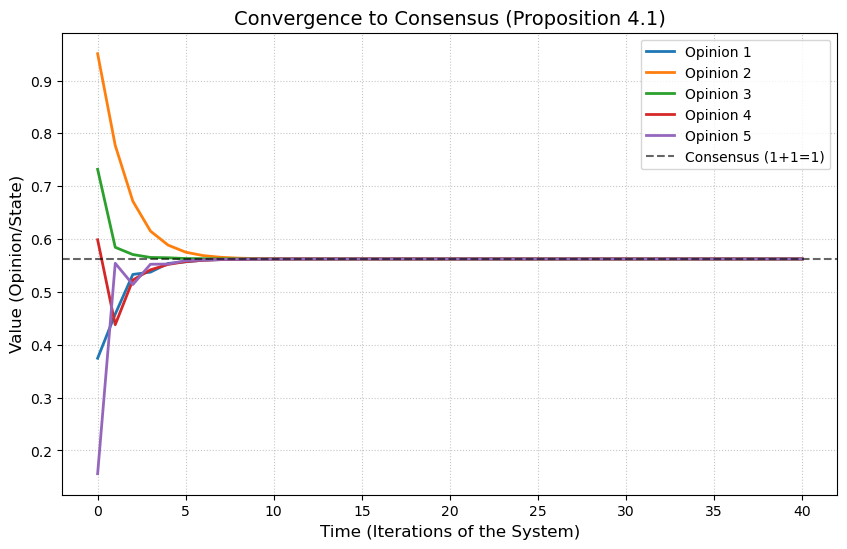

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Set parameters
N = 5  # Number of points/agents on the disk
T = 40 # Time steps for convergence
np.random.seed(42)

def simulate_proposition():
    # 1. Initialize random opinions b(0)
    b = np.random.rand(N)
    
    # 2. Create a Doubly Stochastic Matrix M
    # According to Proposition 4.1, this ensures convergence to the simple average.
    M = np.random.rand(N, N)
    # Sinkhorn-Knopp-like normalization to make it doubly stochastic
    for _ in range(10):
        M /= M.sum(axis=1)[:, None]
        M /= M.sum(axis=0)[None, :]
    
    # Track the history of opinions
    history = [b.copy()]
    for t in range(T):
        b = M @ b
        history.append(b.copy())
    
    return np.array(history), np.mean(history[0])

# Run simulation
history, initial_mean = simulate_proposition()

# Plotting the convergence
plt.figure(figsize=(10, 6))
for i in range(N):
    plt.plot(history[:, i], label=f'Opinion {i+1}', linewidth=2)

plt.axhline(y=initial_mean, color='black', linestyle='--', alpha=0.6, label='Consensus (1+1=1)')
plt.title('Convergence to Consensus (Proposition 4.1)', fontsize=14)
plt.xlabel('Time (Iterations of the System)', fontsize=12)
plt.ylabel('Value (Opinion/State)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.savefig('consensus_convergence.png')

Row sums: [1. 1. 1. 1. 1. 1.]
Column sums: [3.6  0.48 0.48 0.48 0.48 0.48]


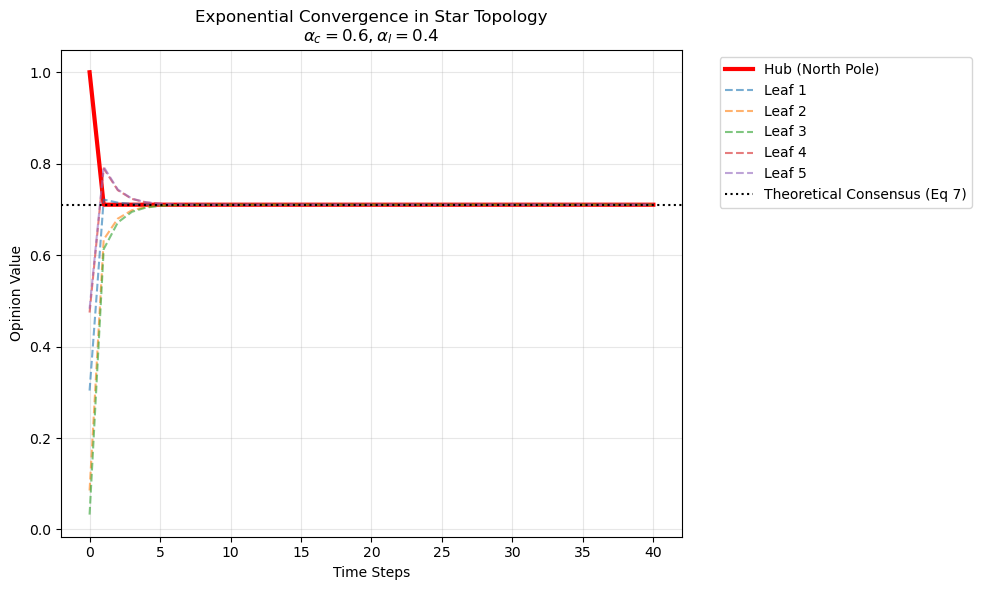

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for Star Topology
N_leaves = 5
N_total = N_leaves + 1  # Hub + Leaves
T = 40

# alpha_c: How much the Hub trusts itself
# alpha_l: How much a Leaf trusts itself
alpha_c = 0.6
alpha_l = 0.4

# Initial values (opinions)
# Let's say the Hub (index 0) starts at 1.0, and leaves start at 0.0
b = np.zeros(N_total)
b[0] = 1.0  # The Hub's initial "truth"
b[1:] = np.random.rand(N_leaves) * 0.5 # Random leaf opinions

def simulate_star_topology(b, alpha_c, alpha_l, steps):
    history = [b.copy()]
    
    # Construct the Star Matrix M
    M = np.zeros((N_total, N_total))
    
    # Hub (Row 0): Trusts itself alpha_c, splits remaining among leaves
    M[0, 0] = alpha_c
    M[0, 1:] = (1 - alpha_c) / N_leaves
    
    # Leaves (Rows 1 to N): Trust themselves alpha_l, trust hub (1 - alpha_l)
    for i in range(1, N_total):
        M[i, i] = alpha_l
        M[i, 0] = 1 - alpha_l
        
    # Check if Row Stochastic (should be)
    print(f"Row sums: {M.sum(axis=1)}") 
    # Check if Column Stochastic (should NOT be)
    print(f"Column sums: {M.sum(axis=0)}") 
    
    for _ in range(steps):
        b = M @ b
        history.append(b.copy())
    return np.array(history), M

history, M = simulate_star_topology(b, alpha_c, alpha_l, T)

# Calculate Theoretical Consensus from Eq (7) in your image
w_j = 1 / N_leaves # assuming equal weight for leaves
leaf_sum = np.sum(history[0, 1:]) * w_j
denom = 2 - alpha_l - alpha_c
theoretical_b = ((1 - alpha_l) / denom) * history[0, 0] + ((1 - alpha_c) / denom) * leaf_sum

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(history[:, 0], 'r-', linewidth=3, label='Hub (North Pole)')
for i in range(1, N_total):
    plt.plot(history[:, i], '--', alpha=0.6, label=f'Leaf {i}')

plt.axhline(y=theoretical_b, color='black', linestyle=':', label='Theoretical Consensus (Eq 7)')
plt.title(f'Exponential Convergence in Star Topology\n$\\alpha_c={alpha_c}, \\alpha_l={alpha_l}$')
plt.xlabel('Time Steps')
plt.ylabel('Opinion Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


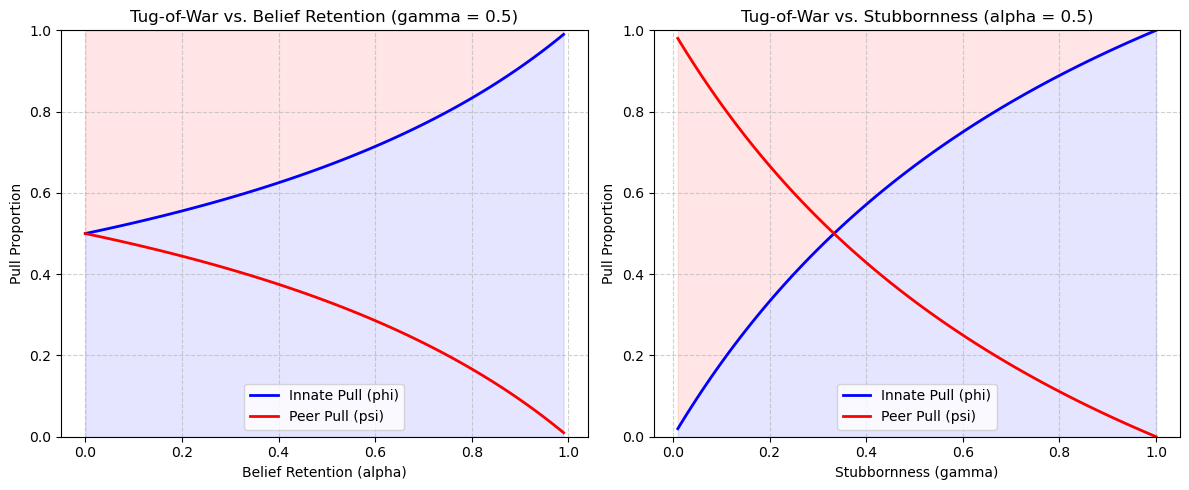

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_pulls(gamma, alpha):
    """
    Calculates the Effective Innate Pull (phi) and Effective Peer Pull (psi).
    """
    # Calculate Openness (R) and Influence Weight (I)
    R = 1 - (1 - gamma) * alpha
    I = (1 - gamma) * (1 - alpha)
    
    # Calculate the final pulls
    phi = gamma / R
    psi = I / R
    
    return phi, psi

# Set up the figure for side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Varying Alpha (Retention) with fixed Gamma = 0.5 ---
# Create an array of 100 values from 0 to 0.99 for alpha
alpha_values = np.linspace(0, 0.99, 100) 
gamma_fixed = 0.5

# Calculate pulls
phi_1, psi_1 = calculate_pulls(gamma_fixed, alpha_values)

# Plot lines and fill the areas
ax1.plot(alpha_values, phi_1, label='Innate Pull (phi)', color='blue', linewidth=2)
ax1.plot(alpha_values, psi_1, label='Peer Pull (psi)', color='red', linewidth=2)
ax1.fill_between(alpha_values, 0, phi_1, color='blue', alpha=0.1)
ax1.fill_between(alpha_values, phi_1, 1, color='red', alpha=0.1) 

# Formatting Plot 1
ax1.set_title('Tug-of-War vs. Belief Retention (gamma = 0.5)')
ax1.set_xlabel('Belief Retention (alpha)')
ax1.set_ylabel('Pull Proportion')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Varying Gamma (Stubbornness) with fixed Alpha = 0.5 ---
# Create an array of 100 values from 0.01 to 1 for gamma
gamma_values = np.linspace(0.01, 1, 100) 
alpha_fixed = 0.5

# Calculate pulls
phi_2, psi_2 = calculate_pulls(gamma_values, alpha_fixed)

# Plot lines and fill the areas
ax2.plot(gamma_values, phi_2, label='Innate Pull (phi)', color='blue', linewidth=2)
ax2.plot(gamma_values, psi_2, label='Peer Pull (psi)', color='red', linewidth=2)
ax2.fill_between(gamma_values, 0, phi_2, color='blue', alpha=0.1)
ax2.fill_between(gamma_values, phi_2, 1, color='red', alpha=0.1)

# Formatting Plot 2
ax2.set_title('Tug-of-War vs. Stubbornness (alpha = 0.5)')
ax2.set_xlabel('Stubbornness (gamma)')
ax2.set_ylabel('Pull Proportion')
ax2.legend()
ax2.set_ylim(0, 1)
ax2.grid(True, linestyle='--', alpha=0.6)

# Display the graphs
plt.tight_layout()
plt.show()

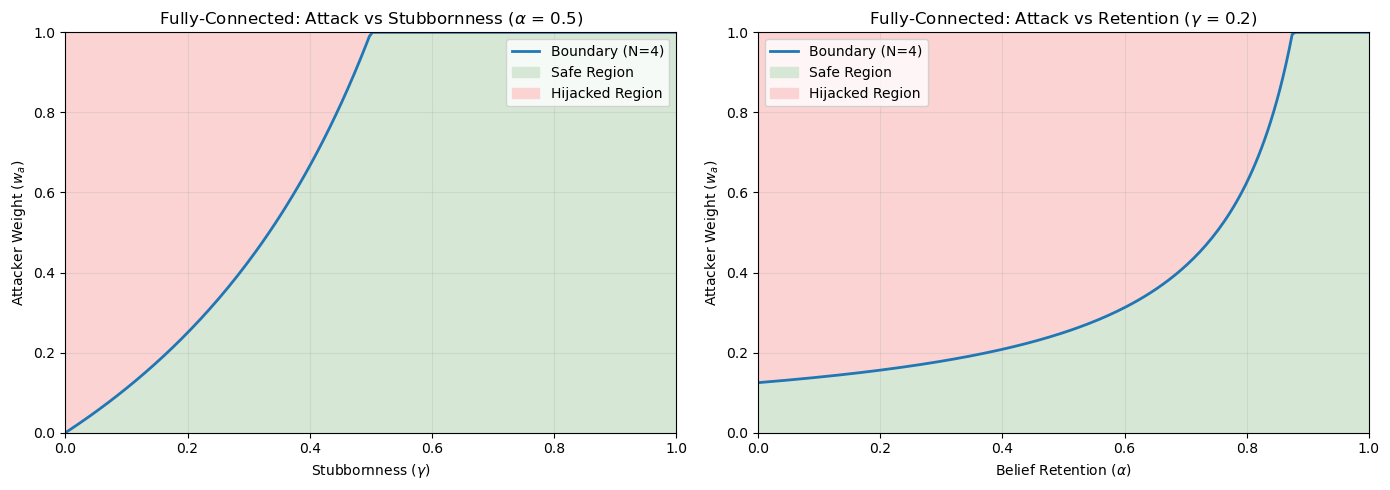

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_psi(gamma, alpha):
    """Calculates Effective Peer Pull (psi) from gamma and alpha."""
    R = 1 - (1 - gamma) * alpha
    I = (1 - gamma) * (1 - alpha)
    # Avoid division by zero if R is 0
    return np.where(R == 0, 0, I / R)

def attacker_boundary_wa(psi):
    """
    Calculates the critical attacker weight (wa) boundary.
    Approximated from the Fully-Connected N=4 graph in the image.
    Formula used: wa = (1 - psi) / (2 * psi)
    """
    # Avoid division by zero
    psi_safe = np.where(psi <= 0.01, 0.01, psi) 
    wa = (1 - psi_safe) / (2 * psi_safe)
    # Cap the output between 0 and 1 to match the graph axes
    return np.clip(wa, 0, 1)

# Set up the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Attacker Weight vs. Stubbornness (gamma) ---
# Assuming a moderate belief retention (alpha = 0.5)
gamma_vals = np.linspace(0, 1, 200)
alpha_fixed = 0.5

psi_from_gamma = calculate_psi(gamma_vals, alpha_fixed)
wa_boundary_1 = attacker_boundary_wa(psi_from_gamma)

ax1.plot(gamma_vals, wa_boundary_1, color='#1f77b4', linewidth=2, label='Boundary (N=4)')
ax1.fill_between(gamma_vals, 0, wa_boundary_1, color='#d6e8d5', label='Safe Region')
ax1.fill_between(gamma_vals, wa_boundary_1, 1, color='#fcd3d3', label='Hijacked Region')

ax1.set_title('Fully-Connected: Attack vs Stubbornness ($\\alpha$ = 0.5)')
ax1.set_xlabel('Stubbornness ($\\gamma$)')
ax1.set_ylabel('Attacker Weight ($w_a$)')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- Plot 2: Attacker Weight vs. Belief Retention (alpha) ---
# Assuming a low baseline stubbornness (gamma = 0.2)
alpha_vals = np.linspace(0, 1, 200)
gamma_fixed = 0.2

psi_from_alpha = calculate_psi(gamma_fixed, alpha_vals)
wa_boundary_2 = attacker_boundary_wa(psi_from_alpha)

ax2.plot(alpha_vals, wa_boundary_2, color='#1f77b4', linewidth=2, label='Boundary (N=4)')
ax2.fill_between(alpha_vals, 0, wa_boundary_2, color='#d6e8d5', label='Safe Region')
ax2.fill_between(alpha_vals, wa_boundary_2, 1, color='#fcd3d3', label='Hijacked Region')

ax2.set_title('Fully-Connected: Attack vs Retention ($\\gamma$ = 0.2)')
ax2.set_xlabel('Belief Retention ($\\alpha$)')
ax2.set_ylabel('Attacker Weight ($w_a$)')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()